# Heart Disease Prediction — 2767: Machine Learning Group Work

### **GROUP W**
| Name | Student Number |
| :--- | :--- |
| Artur Bastos | 52011 |
| Arslan Mubarak | 70864 |
| Benedikt Kasior | 70365 |
| Dominik Holenstein | 70135 |
| Luca Illies | 70170 |
| Miklós Schieszler | 70690 |

---

## Business Problem & Context

In modern healthcare systems, the high volume of patients requiring cardiovascular screenings often leads to significant delays in diagnosis and strained medical resources. Early detection is critical, but detailed clinical consultations are time-consuming and expensive.

Our team is acting as the **internal data science department for a regional hospital network** aiming to implement a preliminary digital screening tool. The objective is to develop a machine learning model that uses **routine patient metrics** (age, cholesterol, EKG results, etc.) to accurately flag high-risk individuals.

By automating the identification of heart disease presence, the hospital can:
- **Prioritise** high-risk patients for urgent specialist review
- **Reduce** unnecessary invasive procedures for low-risk individuals
- **Optimise** allocation of medical staff and diagnostic resources

### Why Recall is the Primary Metric

In this clinical context, a **False Negative** — predicting "Absence" when the patient actually has heart disease — carries a far greater cost than a **False Positive**. A missed diagnosis can lead to delayed treatment, deteriorating patient health, or fatal outcomes, while an unnecessary referral merely incurs a manageable cost of an additional specialist consultation.

> **Primary metric: Recall for `Presence` class (target ≥ 0.90)**  
> **Supporting metrics: ROC-AUC and F1-Score**

We deliberately tune the decision threshold to achieve at least **90% recall** on the positive class, accepting a lower precision as the price for patient safety.

---

## Table of Contents
1. [Imports & Data Loading](#1)
2. [Initial Sense Check](#2)
3. [Target Variable Analysis](#3)
4. [Feature Distributions](#4)
5. [Correlation Analysis](#5)
6. [Bivariate Analysis — Features vs Target](#6)
7. [Outlier Detection](#7)
8. [Key EDA Takeaways](#8)
9. [Preprocessing & Feature Engineering](#9)
10. [Train / Val / Test Split](#10)
11. [Threshold Tuning Strategy](#11)
12. [Model 1 — Logistic Regression](#12)
13. [Model 2 — Random Forest](#13)
14. [Model 3 — HistGradientBoosting](#14)
15. [Model Comparison](#15)
16. [ROC & Precision-Recall Curves](#16)
17. [Predictions & Submission](#17)
18. [Business Conclusions](#18)


## 1. Imports & Data Loading <a id='1'></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, roc_auc_score, f1_score, recall_score, precision_score,
    classification_report, ConfusionMatrixDisplay,
    RocCurveDisplay, PrecisionRecallDisplay,
    precision_recall_curve
)
import gc, warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", "{:.2f}".format)
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110

SEED = 42
np.random.seed(SEED)
print("Libraries loaded.")

Libraries loaded.


In [2]:
def downcast(df):
    """Reduce memory footprint by downcasting numeric columns."""
    for col in df.select_dtypes('float64').columns:
        df[col] = df[col].astype('float32')
    for col in df.select_dtypes('int64').columns:
        df[col] = df[col].astype('int32')
    return df

df = downcast(pd.read_csv("train.csv"))
test_df = pd.read_csv("test.csv")  # label-free; used for final submission only

# Encode target as binary integer for numeric operations
df["target"] = (df["Heart Disease"] == "Presence").astype(int)

# Rename columns to snake_case for convenience
df.columns = [c.strip().lower().replace(" ", "_") for c in df.columns]
df = df.rename(columns={"heart_disease": "heart_disease", "target": "target"})

print(f"Train loaded : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Test loaded  : {test_df.shape[0]:,} rows × {test_df.shape[1]} columns")
print(f"RAM (train)  : {df.memory_usage(deep=True).sum()/1e6:.1f} MB")
df.head()

Train loaded : 630,000 rows × 16 columns
Test loaded  : 270,000 rows × 14 columns
RAM (train)  : 75.9 MB


,id,age,sex,chest_pain_type,bp,cholesterol,fbs_over_120,ekg_results,max_hr,exercise_angina,st_depression,slope_of_st,number_of_vessels_fluro,thallium,heart_disease,target
0,0,58,1,4,152,239,0,0,158,1,3.60,2,2,7,Presence,1
1,1,52,1,1,125,325,0,2,171,0,0.00,1,0,3,Absence,0
2,2,56,0,2,160,188,0,2,151,0,0.00,1,0,3,Absence,0
3,3,44,0,3,134,229,0,2,150,0,1.00,2,0,3,Absence,0
4,4,58,1,4,140,234,0,2,125,1,3.80,2,3,3,Presence,1


## 2. Initial Sense Check <a id='2'></a>

Before any analysis, we perform a systematic data quality audit covering:
- **Shape & data types** — confirm features are correctly typed
- **Missing values** — identify columns that may require imputation
- **Duplicate rows** — exact duplicates can bias model training and inflate evaluation scores
- **Descriptive statistics** — spot implausible ranges early (e.g., negative blood pressure)

This step is essential in a healthcare setting: erroneous data can produce misleading model outputs and, ultimately, incorrect clinical flags.


In [3]:
# Shape & dtypes
print("=== Shape ===")
print(f"{df.shape[0]:,} rows, {df.shape[1]} columns\n")

print("=== Column names & dtypes ===")
print(df.dtypes.to_string())

=== Shape ===
630,000 rows, 16 columns

=== Column names & dtypes ===
id                           int32
age                          int32
sex                          int32
chest_pain_type              int32
bp                           int32
cholesterol                  int32
fbs_over_120                 int32
ekg_results                  int32
max_hr                       int32
exercise_angina              int32
st_depression              float32
slope_of_st                  int32
number_of_vessels_fluro      int32
thallium                     int32
heart_disease               object
target                       int64


In [4]:
# Missing values
print("=== Missing Values ===")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({"count": missing, "%": missing_pct})
print(missing_df[missing_df["count"] > 0].to_string()
      if missing_df["count"].sum() > 0 else "No missing values found.")

=== Missing Values ===
No missing values found.


In [5]:
# Duplicates
n_dups = df.duplicated().sum()
print(f"=== Duplicate Rows ===")
print(f"{n_dups:,} exact duplicate rows ({n_dups/len(df)*100:.2f}%)")

if n_dups > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print(f"Duplicates removed. New shape: {df.shape}")

=== Duplicate Rows ===
0 exact duplicate rows (0.00%)


In [6]:
# Descriptive statistics
print("=== Descriptive Statistics (numeric features) ===")
stat_cols = [c for c in df.select_dtypes(include=np.number).columns if c not in ["id", "target"]]
df[stat_cols].describe().T.style.background_gradient(cmap="Blues", axis=1)

=== Descriptive Statistics (numeric features) ===


,count,mean,std,min,25%,50%,75%,max
age,630000.000000,54.136706,8.256301,29.000000,48.000000,54.000000,60.000000,77.000000
sex,630000.000000,0.714735,0.451541,0.000000,0.000000,1.000000,1.000000,1.000000
chest_pain_type,630000.000000,3.312752,0.851615,1.000000,3.000000,4.000000,4.000000,4.000000
bp,630000.000000,130.497433,14.975802,94.000000,120.000000,130.000000,140.000000,200.000000
cholesterol,630000.000000,245.011814,33.681581,126.000000,223.000000,243.000000,269.000000,564.000000
fbs_over_120,630000.000000,0.079987,0.271274,0.000000,0.000000,0.000000,0.000000,1.000000
ekg_results,630000.000000,0.981660,0.998783,0.000000,0.000000,0.000000,2.000000,2.000000
max_hr,630000.000000,152.816763,19.112927,71.000000,142.000000,157.000000,166.000000,202.000000
exercise_angina,630000.000000,0.273725,0.445870,0.000000,0.000000,0.000000,1.000000,1.000000
st_depression,630000.000000,0.716028,0.947288,0.000000,0.000000,0.100000,1.400000,6.200000


In [7]:
# Value range sanity check
print("=== Feature Value Ranges (sanity check) ===")
range_info = []
for col in stat_cols:
    range_info.append({
        "feature": col,
        "min": df[col].min(),
        "max": df[col].max(),
        "unique_values": df[col].nunique(),
        "zero_count": (df[col] == 0).sum(),
        "negative_count": (df[col] < 0).sum(),
    })
pd.DataFrame(range_info).set_index("feature")

=== Feature Value Ranges (sanity check) ===


,min,max,unique_values,zero_count,negative_count
feature,,,,,
age,29.00,77.00,42,0,0
sex,0.00,1.00,2,179717,0
chest_pain_type,1.00,4.00,4,0,0
bp,94.00,200.00,66,0,0
cholesterol,126.00,564.00,150,0,0
fbs_over_120,0.00,1.00,2,579608,0
ekg_results,0.00,2.00,3,320116,0
max_hr,71.00,202.00,93,0,0
exercise_angina,0.00,1.00,2,457553,0


## 3. Target Variable Analysis <a id='3'></a>

Understanding the class balance is critical before modelling. In a clinical screening context:
- **Significant imbalance** (e.g., 10% Presence) would mean a naive model could achieve 90% accuracy by always predicting "Absence" — a dangerous outcome.
- If imbalance is detected, we must account for it via `class_weight='balanced'` in our models or oversampling techniques (e.g., SMOTE).

The plots below show both the raw count and the proportional split.


=== Target Distribution ===
  Absence: 347,546  (55.2%)
  Presence: 282,454  (44.8%)


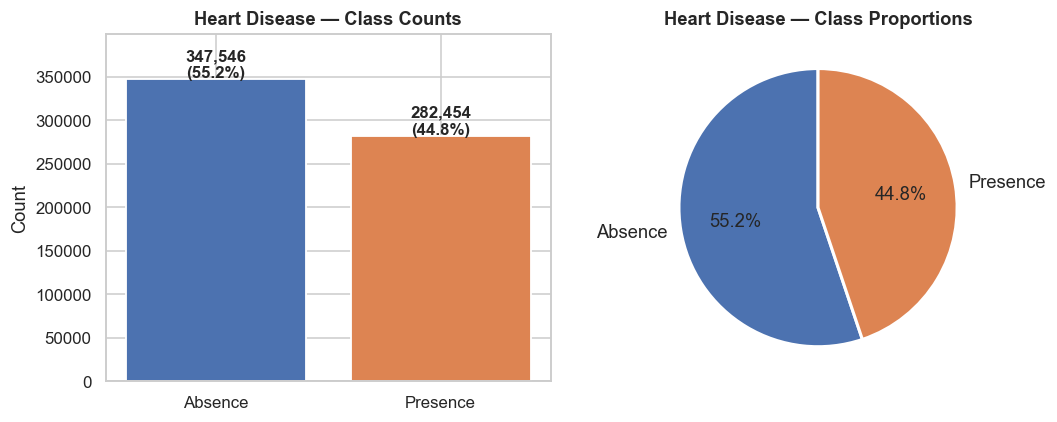

In [8]:
target_counts = df["heart_disease"].value_counts()
target_pct = df["heart_disease"].value_counts(normalize=True) * 100

print("=== Target Distribution ===")
for label, count in target_counts.items():
    print(f"  {label}: {count:,}  ({target_pct[label]:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

colors = ["#4C72B0", "#DD8452"]
axes[0].bar(target_counts.index, target_counts.values, color=colors, edgecolor="white", linewidth=1.2)
for i, (label, count) in enumerate(target_counts.items()):
    axes[0].text(i, count + 1500, f"{count:,}\n({target_pct[label]:.1f}%)",
                 ha="center", fontsize=11, fontweight="bold")
axes[0].set_title("Heart Disease — Class Counts", fontweight="bold")
axes[0].set_ylabel("Count")
axes[0].set_ylim(0, target_counts.max() * 1.15)

axes[1].pie(target_counts.values, labels=target_counts.index, autopct="%1.1f%%",
            colors=colors, startangle=90, wedgeprops=dict(edgecolor="white", linewidth=2),
            textprops={"fontsize": 12})
axes[1].set_title("Heart Disease — Class Proportions", fontweight="bold")

plt.tight_layout()
plt.show()

## 4. Feature Distributions <a id='4'></a>

We examine each feature independently to understand its spread, skewness, and potential issues before modelling.

### 4a. Continuous Features

The five continuous features represent core clinical measurements. Key things to observe:
- **Skewness**: Right-skewed features (e.g., `st_depression`) may benefit from log-transformation.
- **Mean vs. Median divergence**: A large gap signals skewness or influential outliers.
- **Physiologically plausible ranges**: Extremely high cholesterol or BP values warrant outlier investigation.


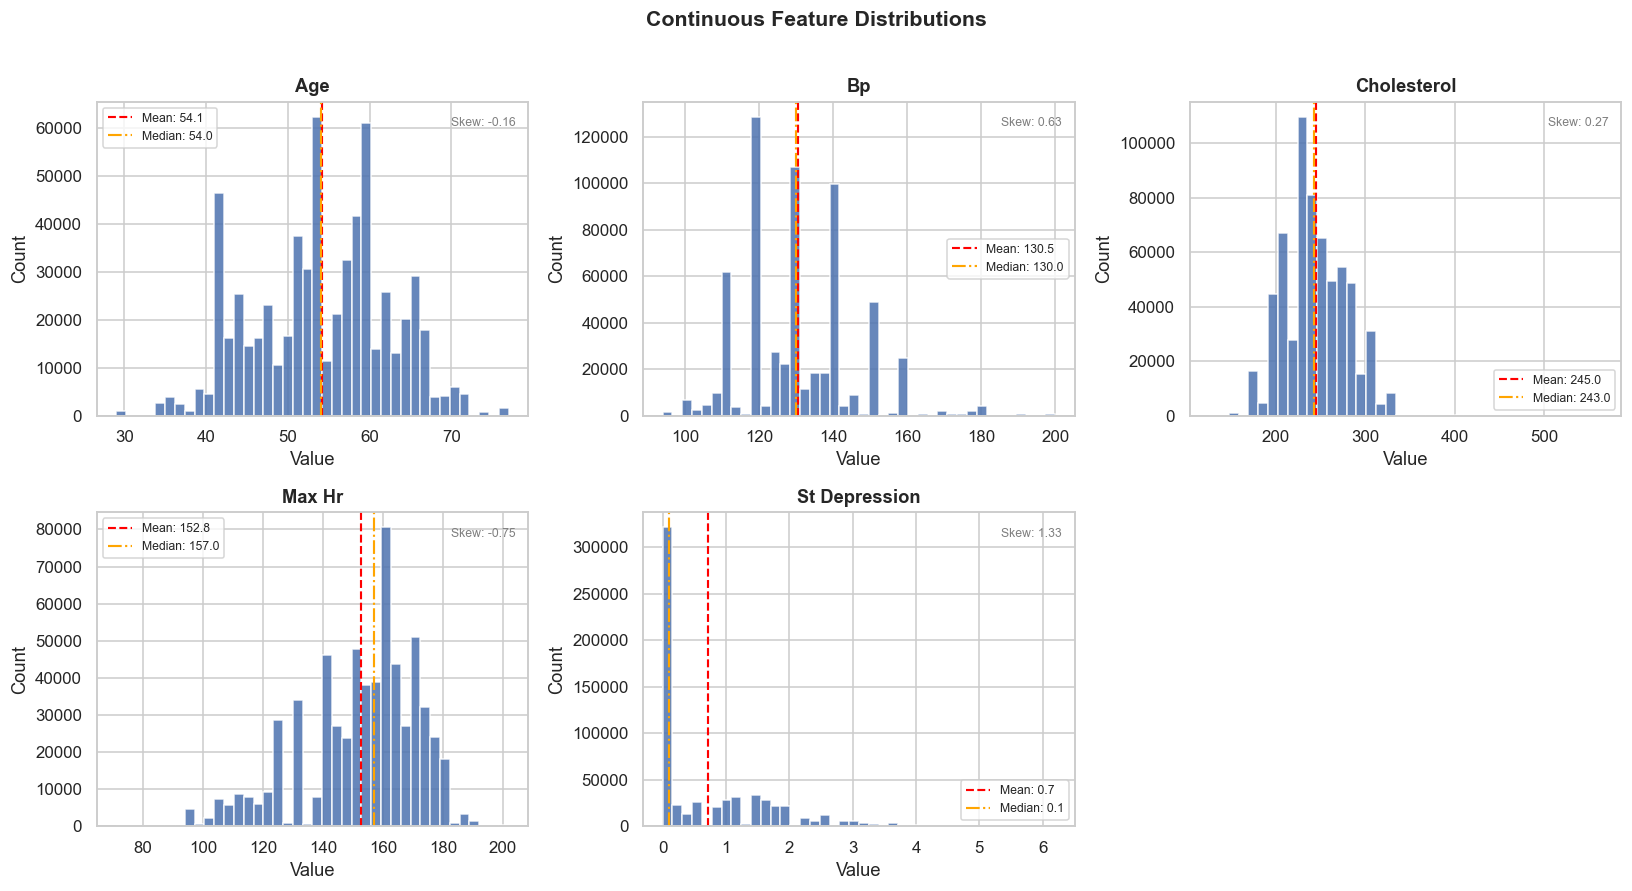

In [9]:
continuous_features = ["age", "bp", "cholesterol", "max_hr", "st_depression"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(continuous_features):
    ax = axes[i]
    data = df[col].dropna()
    ax.hist(data, bins=40, color="#4C72B0", edgecolor="white", alpha=0.85)
    ax.axvline(data.mean(), color="red", linestyle="--", linewidth=1.4, label=f"Mean: {data.mean():.1f}")
    ax.axvline(data.median(), color="orange", linestyle="-.", linewidth=1.4, label=f"Median: {data.median():.1f}")
    ax.set_title(col.replace("_", " ").title(), fontweight="bold")
    ax.set_xlabel("Value")
    ax.set_ylabel("Count")
    ax.legend(fontsize=8)
    skew = data.skew()
    ax.text(0.97, 0.95, f"Skew: {skew:.2f}", transform=ax.transAxes,
            ha="right", va="top", fontsize=8, color="gray")

axes[-1].set_visible(False)
plt.suptitle("Continuous Feature Distributions", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

### 4b. Categorical / Ordinal Features

These features capture clinical findings and patient demographics. We inspect their frequency distribution to check for:
- **Rare categories** that may need grouping
- **Dominant categories** that could reduce a feature's discriminative power
- **Data entry anomalies** (e.g., unexpected codes)


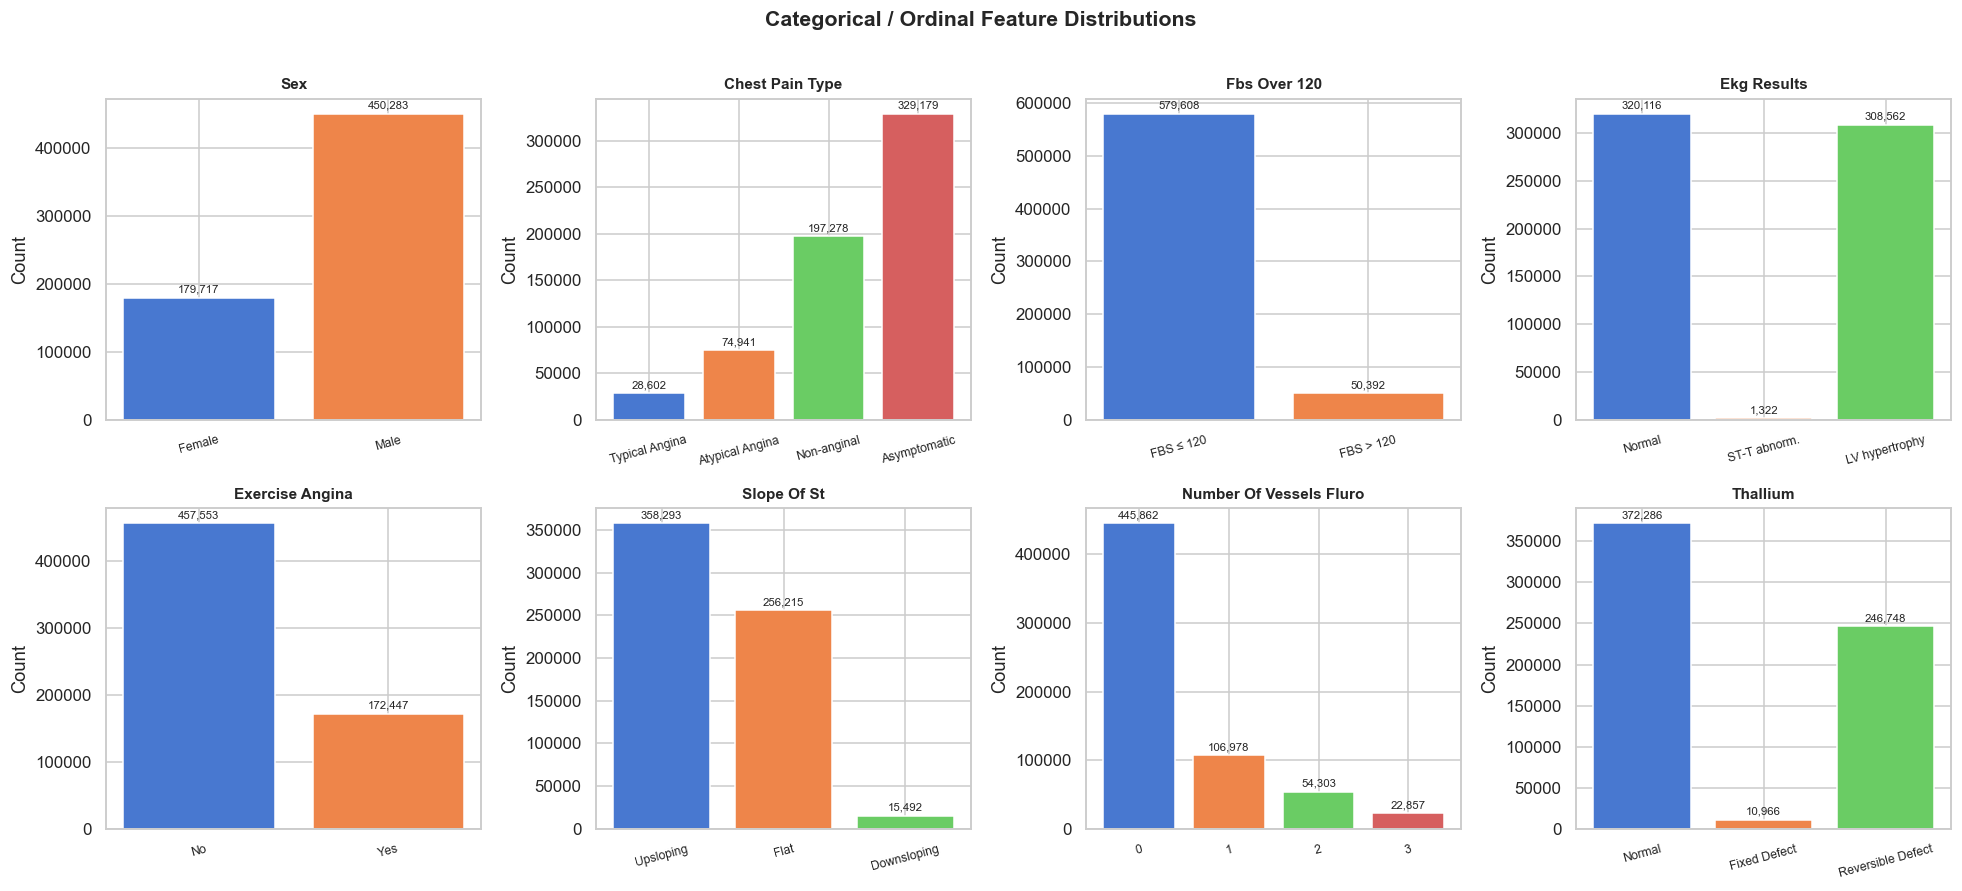

In [10]:
categorical_features = {
    "sex":                     {0: "Female", 1: "Male"},
    "chest_pain_type":         {1: "Typical Angina", 2: "Atypical Angina", 3: "Non-anginal", 4: "Asymptomatic"},
    "fbs_over_120":            {0: "FBS ≤ 120", 1: "FBS > 120"},
    "ekg_results":             {0: "Normal", 1: "ST-T abnorm.", 2: "LV hypertrophy"},
    "exercise_angina":         {0: "No", 1: "Yes"},
    "slope_of_st":             {1: "Upsloping", 2: "Flat", 3: "Downsloping"},
    "number_of_vessels_fluro": {0: "0", 1: "1", 2: "2", 3: "3"},
    "thallium":                {3: "Normal", 6: "Fixed Defect", 7: "Reversible Defect"},
}

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, (col, label_map) in enumerate(categorical_features.items()):
    ax = axes[i]
    counts = df[col].value_counts().sort_index()
    labels = [label_map.get(k, str(k)) for k in counts.index]
    bars = ax.bar(labels, counts.values, color=sns.color_palette("muted", len(counts)),
                  edgecolor="white", linewidth=1)
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + counts.max() * 0.01,
                f"{val:,}", ha="center", va="bottom", fontsize=7.5)
    ax.set_title(col.replace("_", " ").title(), fontweight="bold", fontsize=10)
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", labelsize=8, rotation=15)

plt.suptitle("Categorical / Ordinal Feature Distributions", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

## 5. Correlation Analysis <a id='5'></a>

The Pearson correlation matrix reveals linear relationships between all numeric features and the target. In clinical data:
- **Positive correlation with target**: feature values tend to be higher in patients with heart disease.
- **Negative correlation with target**: feature values tend to be lower in patients with heart disease.

We also inspect inter-feature correlations to identify potential **multicollinearity**, which can inflate coefficient estimates in Logistic Regression and reduce model interpretability. Pairs with `|r| > 0.70` warrant attention.


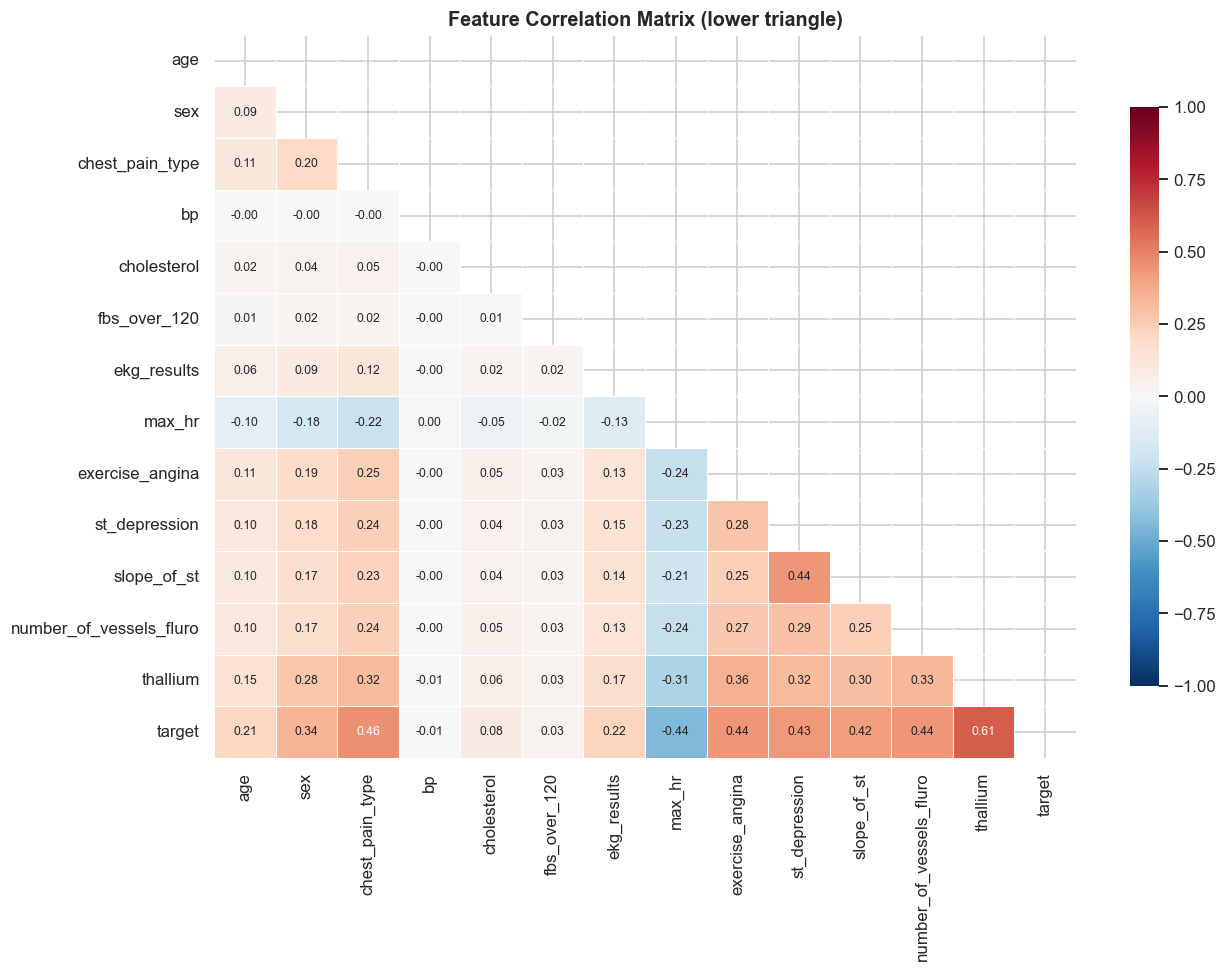

In [11]:
numeric_cols = [c for c in df.select_dtypes(include=np.number).columns if c != "id"]
corr_matrix = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
    center=0, vmin=-1, vmax=1, linewidths=0.5,
    annot_kws={"size": 8}, ax=ax, cbar_kws={"shrink": 0.8}
)
ax.set_title("Feature Correlation Matrix (lower triangle)", fontweight="bold", fontsize=13)
plt.tight_layout()
plt.show()

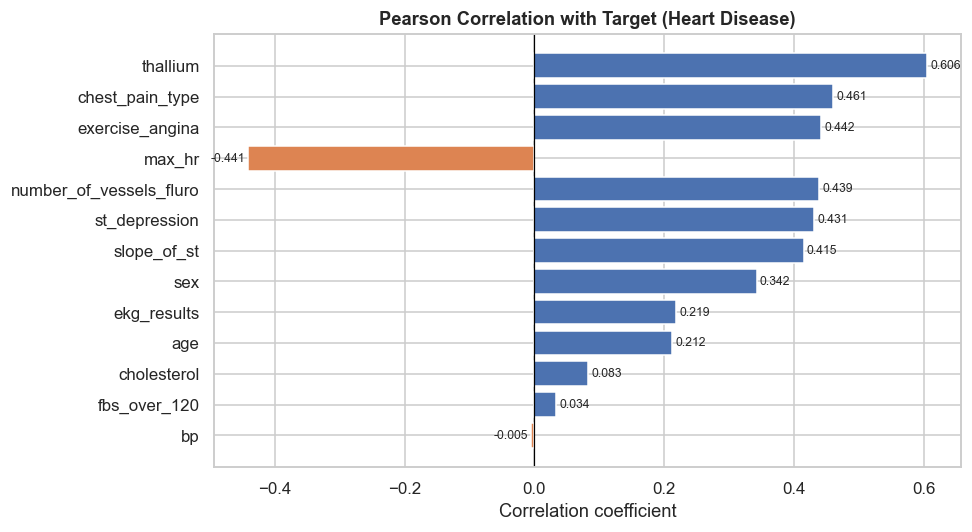

In [12]:
# Correlation with target — ranked bar chart
target_corr = corr_matrix["target"].drop("target").sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
colors_bar = ["#4C72B0" if v > 0 else "#DD8452" for v in target_corr.values]
bars = ax.barh(target_corr.index[::-1], target_corr.values[::-1], color=colors_bar[::-1],
               edgecolor="white")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Pearson Correlation with Target (Heart Disease)", fontweight="bold")
ax.set_xlabel("Correlation coefficient")
for bar, val in zip(bars, target_corr.values[::-1]):
    ax.text(val + (0.005 if val >= 0 else -0.005), bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}", va="center", ha="left" if val >= 0 else "right", fontsize=8)
plt.tight_layout()
plt.show()

## 6. Bivariate Analysis — Features vs Target <a id='6'></a>

Bivariate analysis examines how each feature behaves differently across the two outcome classes (`Absence` vs `Presence`). This is a key step for **feature selection**: features with strong distributional separation between classes will be the most predictive.

From a clinical interpretation standpoint, any feature showing a meaningful difference by class can serve as an early warning signal — precisely what the hospital's screening tool aims to leverage.

### 6a. Continuous Features vs Target (Box Plots)

Box plots compare the central tendency and spread of each continuous feature across classes. Features where the two boxes are clearly separated (non-overlapping interquartile ranges) are strong discriminators.


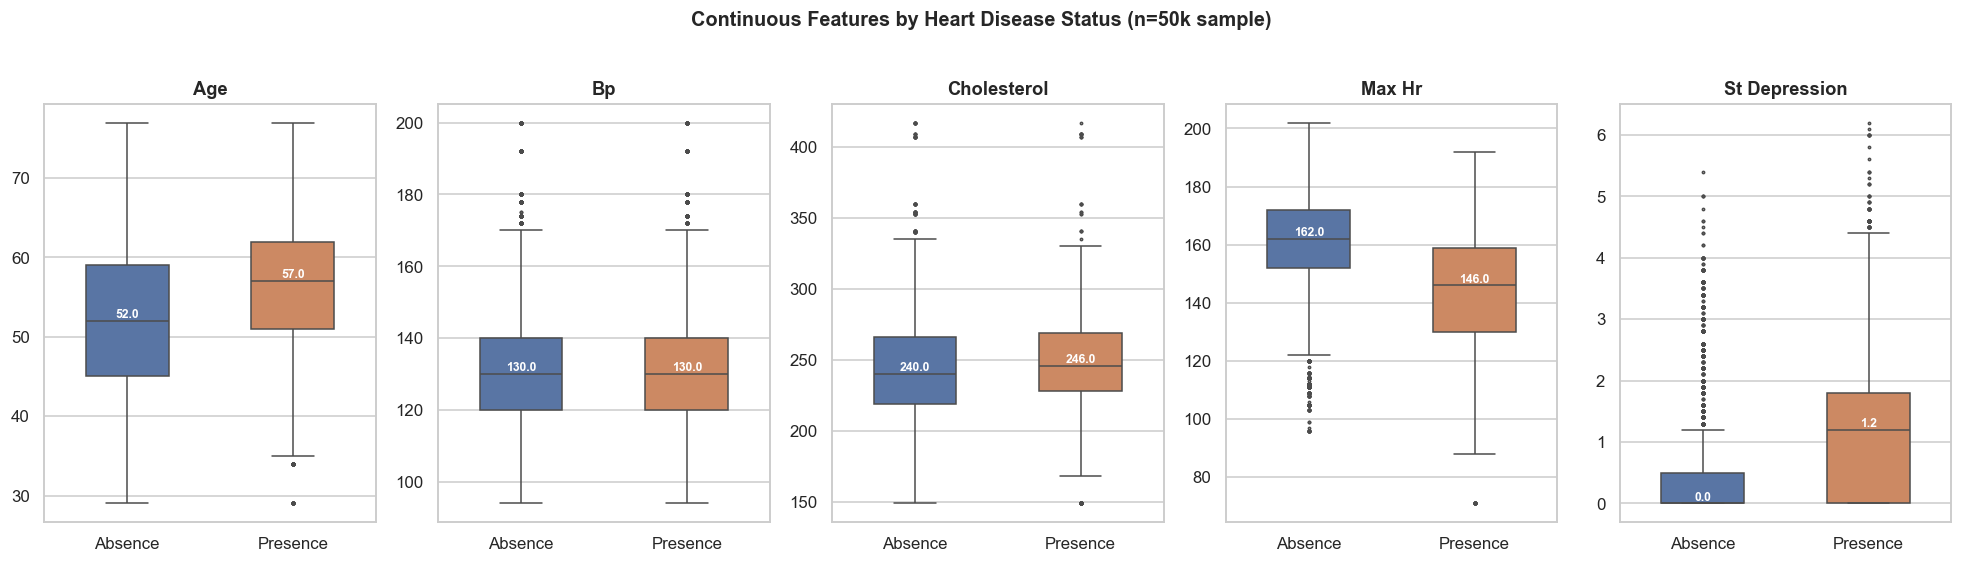

In [13]:
fig, axes = plt.subplots(1, 5, figsize=(18, 5))

for ax, col in zip(axes, continuous_features):
    sample = df.sample(n=min(50_000, len(df)), random_state=42)
    sns.boxplot(data=sample, x="heart_disease", y=col,
                palette={"Absence": "#4C72B0", "Presence": "#DD8452"},
                width=0.5, linewidth=1, fliersize=1.5, ax=ax)
    ax.set_title(col.replace("_", " ").title(), fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("")
    for i, group in enumerate(["Absence", "Presence"]):
        med = sample[sample["heart_disease"] == group][col].median()
        ax.text(i, med, f"{med:.1f}", ha="center", va="bottom",
                fontsize=8, color="white", fontweight="bold")

plt.suptitle("Continuous Features by Heart Disease Status (n=50k sample)",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### 6b. Categorical Features vs Target (Stacked Bar %)

Stacked percentage bars show the **disease prevalence rate within each category**. A category where "Presence" accounts for >70% of cases is a strong positive risk indicator for the model. Categories near the 50% baseline offer little discriminatory power.


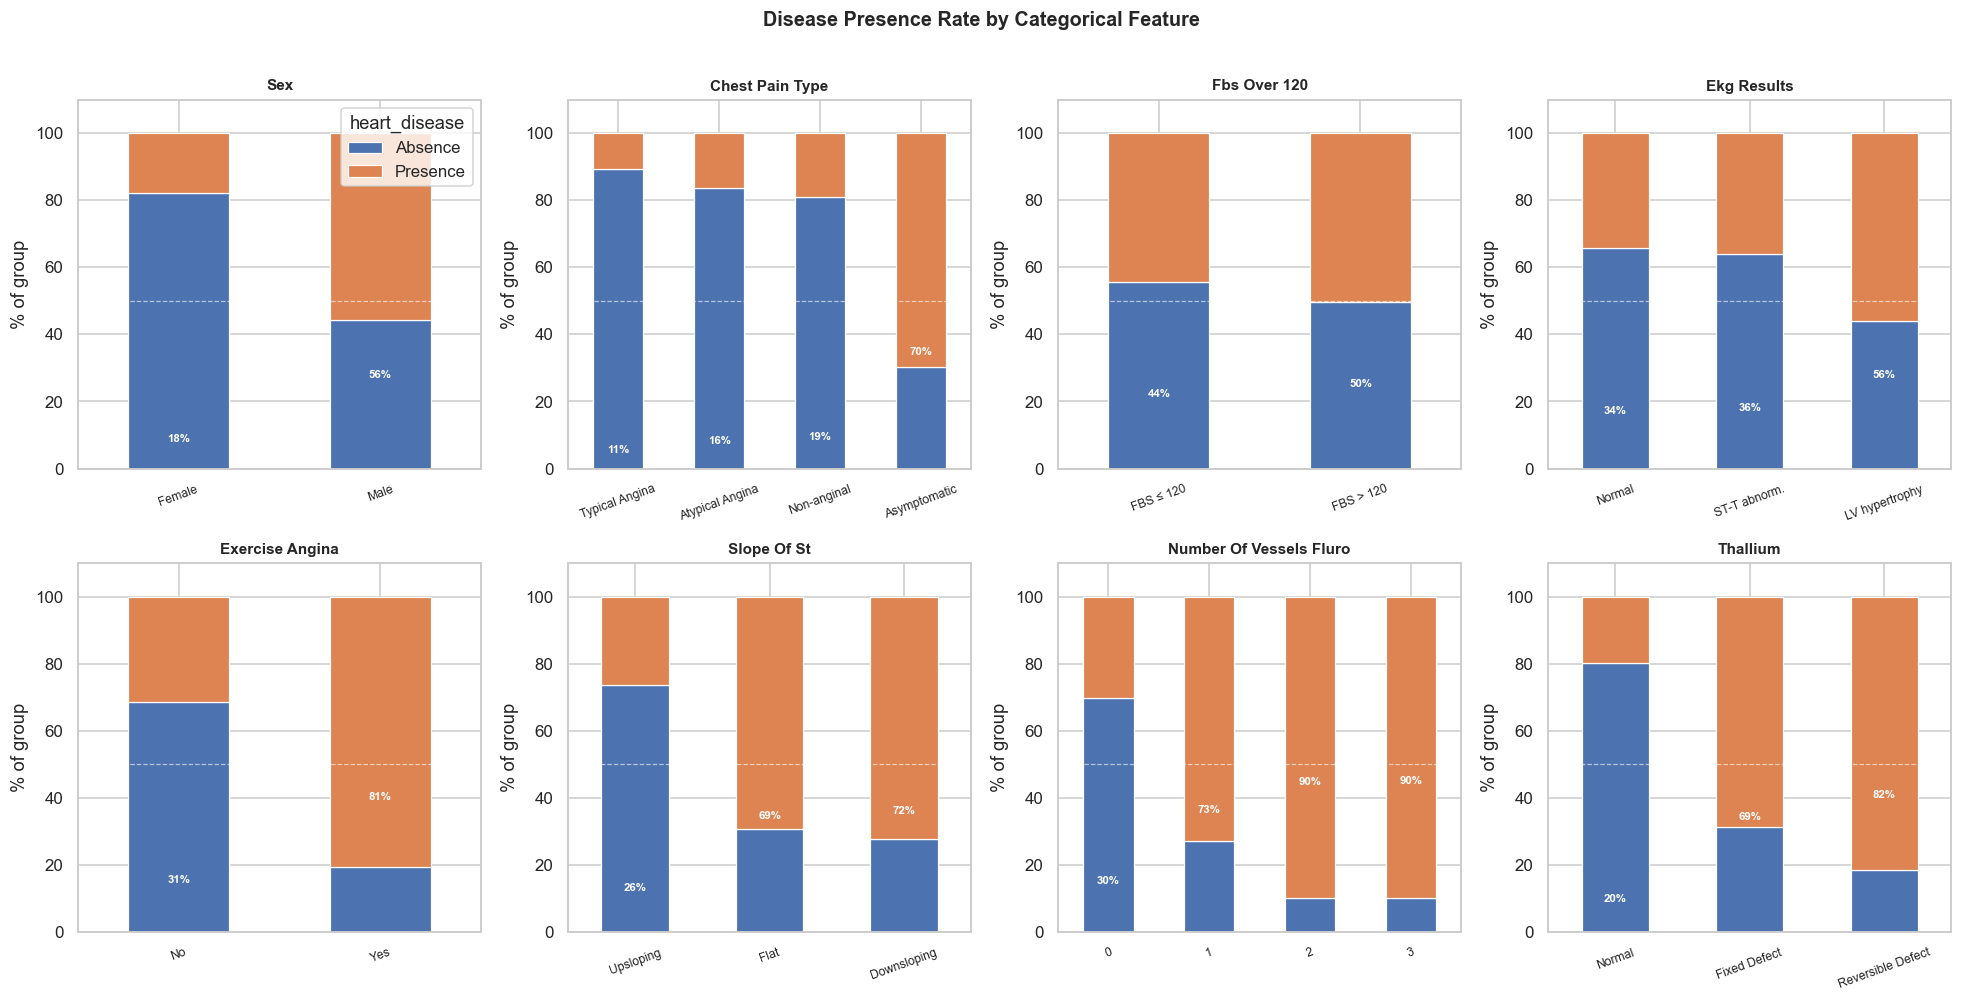

In [14]:
cat_cols = list(categorical_features.keys())
label_maps = categorical_features

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ax = axes[i]
    lmap = label_maps[col]
    ct = pd.crosstab(df[col], df["heart_disease"], normalize="index") * 100
    ct.index = [lmap.get(k, str(k)) for k in ct.index]
    ct[["Absence", "Presence"]].plot(
        kind="bar", stacked=True, ax=ax,
        color=["#4C72B0", "#DD8452"], edgecolor="white", linewidth=0.8, legend=(i == 0)
    )
    ax.set_title(col.replace("_", " ").title(), fontweight="bold", fontsize=10)
    ax.set_xlabel("")
    ax.set_ylabel("% of group")
    ax.set_ylim(0, 110)
    ax.axhline(50, color="white", linestyle="--", linewidth=0.8, alpha=0.6)
    ax.tick_params(axis="x", rotation=20, labelsize=8)
    for j, (idx, row) in enumerate(ct.iterrows()):
        pct = row.get("Presence", 0)
        ax.text(j, pct / 2, f"{pct:.0f}%", ha="center", va="center",
                fontsize=7.5, color="white", fontweight="bold")

plt.suptitle("Disease Presence Rate by Categorical Feature",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

### 6c. Scatter Plots — Age × Max HR and Age × ST Depression

These scatter plots explore **joint relationships** between two continuous features, coloured by class. Clusters that separate cleanly by colour signal that the combination of those two features may provide strong decision boundaries for a classifier.

Clinically: younger patients with high max HR during stress testing and low ST depression are generally lower risk, while older patients with depressed ST segments and limited max HR are higher risk — consistent with established cardiology knowledge.


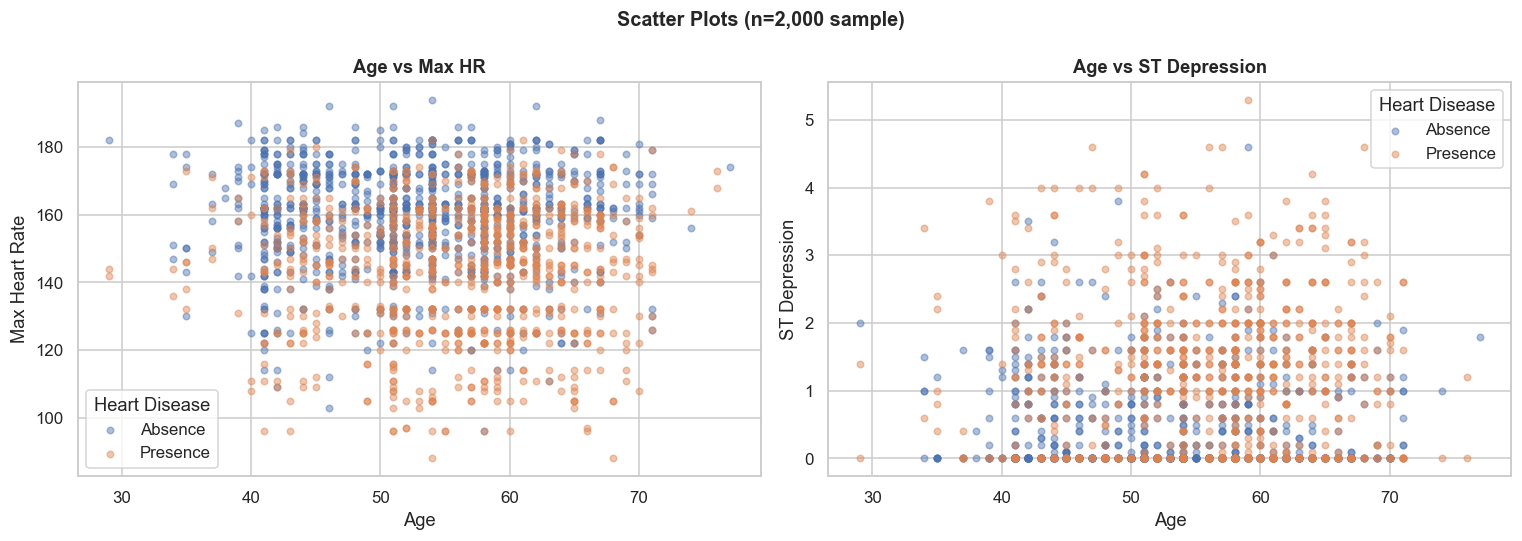

In [15]:
sample2k = df.sample(n=2000, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for label, color in [("Absence", "#4C72B0"), ("Presence", "#DD8452")]:
    sub = sample2k[sample2k["heart_disease"] == label]
    axes[0].scatter(sub["age"], sub["max_hr"], alpha=0.45, s=18, label=label, color=color)
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Max Heart Rate")
axes[0].set_title("Age vs Max HR", fontweight="bold")
axes[0].legend(title="Heart Disease")

for label, color in [("Absence", "#4C72B0"), ("Presence", "#DD8452")]:
    sub = sample2k[sample2k["heart_disease"] == label]
    axes[1].scatter(sub["age"], sub["st_depression"], alpha=0.45, s=18, label=label, color=color)
axes[1].set_xlabel("Age")
axes[1].set_ylabel("ST Depression")
axes[1].set_title("Age vs ST Depression", fontweight="bold")
axes[1].legend(title="Heart Disease")

plt.suptitle("Scatter Plots (n=2,000 sample)", fontweight="bold", fontsize=13)
plt.tight_layout()
plt.show()

## 7. Outlier Detection <a id='7'></a>

Outliers in clinical data can arise from legitimate extreme cases (e.g., very high cholesterol in a hypercholesterolemia patient) or from data entry errors. We use the **IQR method** (flagging values below Q1 − 1.5×IQR or above Q3 + 1.5×IQR) as a systematic baseline.

Key considerations:
- In tree-based models (Random Forest, HistGBM), outliers typically have minimal impact as splits are rank-based.
- In Logistic Regression, extreme values can distort the decision boundary, so capping or log-transformation may help.
- Given the large dataset size (630k rows), we retain borderline outliers unless they are clearly erroneous.


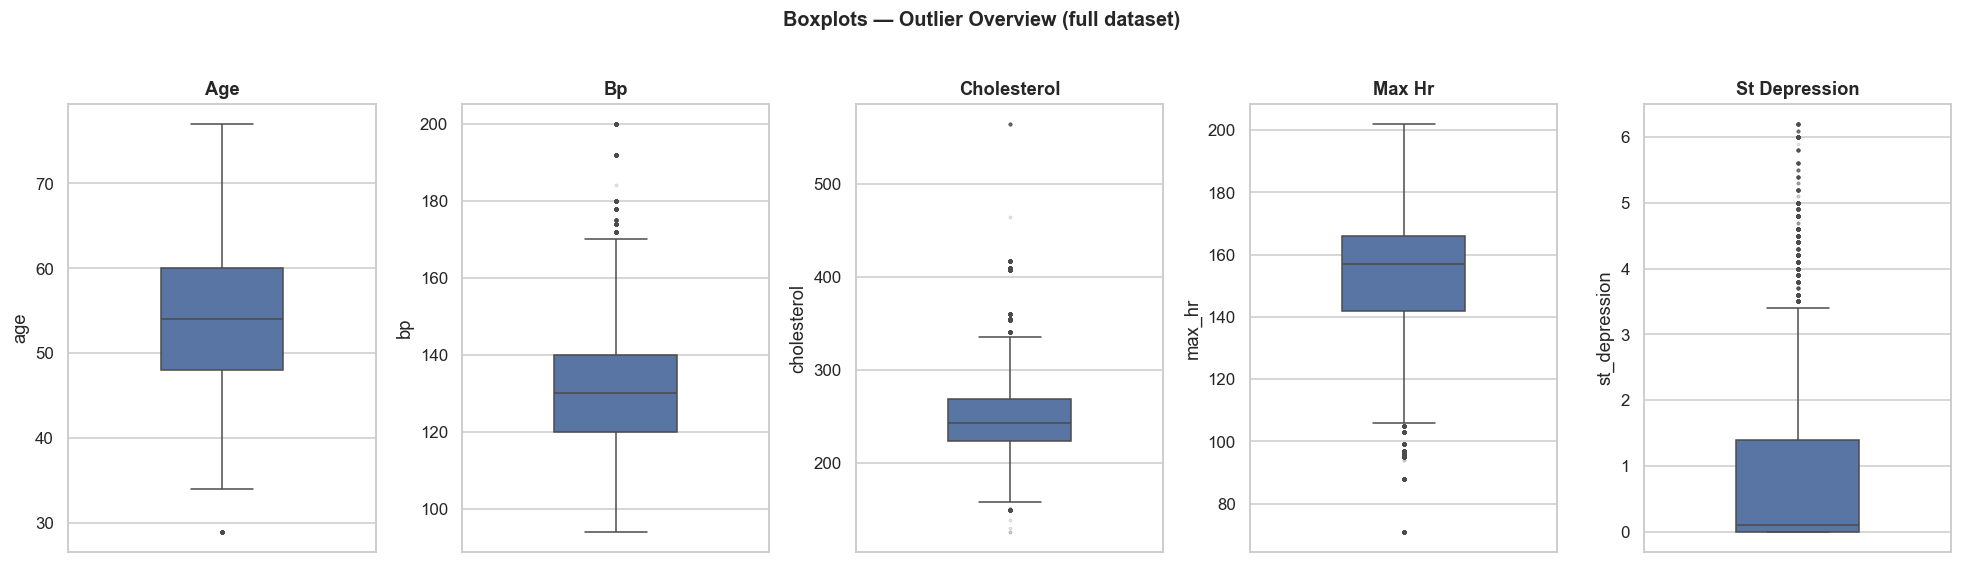

In [16]:
fig, axes = plt.subplots(1, 5, figsize=(18, 5))

for ax, col in zip(axes, continuous_features):
    sns.boxplot(y=df[col], color="#4C72B0", width=0.4, fliersize=1.5,
                linewidth=1, flierprops={"alpha": 0.2}, ax=ax)
    ax.set_title(col.replace("_", " ").title(), fontweight="bold")
    ax.set_xlabel("")

plt.suptitle("Boxplots — Outlier Overview (full dataset)", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

In [17]:
# IQR-based outlier count per feature
print("=== IQR Outlier Counts ===")
outlier_summary = []
for col in continuous_features:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary.append({
        "feature": col, "Q1": Q1, "Q3": Q3, "IQR": IQR,
        "lower_fence": lower, "upper_fence": upper,
        "n_outliers": n_out, "%_outliers": round(n_out / len(df) * 100, 2)
    })
pd.DataFrame(outlier_summary).set_index("feature")

=== IQR Outlier Counts ===


,Q1,Q3,IQR,lower_fence,upper_fence,n_outliers,%_outliers
feature,,,,,,,
age,48.00,60.00,12.00,30.00,78.00,1048,0.17
bp,120.00,140.00,20.00,90.00,170.00,9011,1.43
cholesterol,223.00,269.00,46.00,154.00,338.00,2194,0.35
max_hr,142.00,166.00,24.00,106.00,202.00,14246,2.26
st_depression,0.00,1.40,1.40,-2.10,3.50,9971,1.58


## 8. Key EDA Takeaways <a id='8'></a>

### Dataset Summary
- **630,000 rows**, 14 features, binary target (`Presence` / `Absence`)
- **No missing values** detected — no imputation required, though we apply it defensively in the pipeline for robustness
- Duplicate rows removed if present

### Class Balance
Check the target distribution plot above. If significant imbalance is present (i.e., one class accounts for less than ~30% of observations), we must account for this via `class_weight='balanced'` in model fitting — which is already implemented in all three models.

### Strongest Predictors (from correlation & bivariate analysis)
| Feature | Clinical Meaning | Direction with Presence |
|---|---|---|
| `chest_pain_type = 4` (Asymptomatic) | Paradoxically, asymptomatic pain is the highest-risk type | ↑ |
| `thallium = 7` (Reversible Defect) | Indicates ischaemia reversible with treatment | ↑ |
| `number_of_vessels_fluro` | More occluded vessels = higher disease burden | ↑ |
| `exercise_angina = 1` | Pain during exercise signals insufficient coronary flow | ↑ |
| `st_depression` | Elevation in depression indicates ischaemia on EKG | ↑ |
| `max_hr` | Lower max HR suggests reduced cardiac reserve | ↓ |
| `slope_of_st` (Flat/Downsloping) | Abnormal ST slope is a classic ischaemic indicator | ↑ |

### Continuous Feature Characteristics
- `age`: roughly normal, centred ~54 years — consistent with cardiovascular disease epidemiology
- `bp` and `cholesterol`: right-skewed with notable high-end outliers — candidates for log-transformation or capping
- `st_depression`: heavily right-skewed with a spike at zero (many patients show no resting depression)

### Modelling Implications
- Use `class_weight='balanced'` to handle any class imbalance
- Apply `StandardScaler` for Logistic Regression (sensitive to feature scale)
- Tree-based models (RF, HGB) are inherently robust to skewness and outliers
- Threshold tuning on a held-out validation set is critical to achieve the ≥ 90% recall target

---


## 9. Preprocessing & Feature Engineering <a id='9'></a>

The preprocessing pipeline consists of three steps:

1. **Feature selection**: All 13 clinical features are retained. No manual feature dropping is performed at this stage — the models, especially tree-based ones, will implicitly down-weight low-importance features.
2. **Median imputation**: Applied defensively using `SimpleImputer(strategy='median')`. Median is preferred over mean for skewed distributions as it is robust to outliers. The imputer is fit only on training data to prevent data leakage.
3. **Standard scaling**: Applied within the Logistic Regression pipeline only. Tree-based models do not require scaling since they operate on ranked splits rather than distances.


In [18]:
FEATURES = [
    'Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol',
    'FBS over 120', 'EKG results', 'Max HR', 'Exercise angina',
    'ST depression', 'Slope of ST', 'Number of vessels fluro', 'Thallium'
]

# Load fresh for modelling (original column names)
train_df = downcast(pd.read_csv("train.csv"))

y_all = (train_df['Heart Disease'] == 'Presence').astype(int)
X_all = train_df[FEATURES].copy()

# Median imputation — fit on training data only to avoid leakage
imputer = SimpleImputer(strategy='median')
X_all = pd.DataFrame(imputer.fit_transform(X_all), columns=FEATURES)
X_test_sub = pd.DataFrame(imputer.transform(test_df[FEATURES]), columns=FEATURES)

print(f"Features used       : {len(FEATURES)}")
print(f"Missing after impute: {X_all.isnull().sum().sum()}")
print(f"Positive rate       : {y_all.mean():.3f}  ({y_all.sum():,} Presence out of {len(y_all):,})")

Features used       : 13
Missing after impute: 0
Positive rate       : 0.448  (282,454 Presence out of 630,000)


## 10. Train / Val / Test Split <a id='10'></a>

We use a **three-way stratified split**:

| Set | Proportion | Purpose |
|---|---|---|
| **Train** | 70% | Fit model weights/trees |
| **Validation** | 15% | Tune the decision threshold (recall optimisation) |
| **Test** | 15% | Final unbiased evaluation — never seen during training or threshold tuning |

**Why a separate validation set?** Tuning the threshold directly on the test set would cause information leakage and produce an overly optimistic recall estimate. The validation set acts as a proxy for unseen data during threshold selection, preserving the integrity of the test set as a true holdout.

**Stratification** ensures the positive rate is consistent across all three splits, which is especially important if there is class imbalance.


In [19]:
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X_all, y_all, test_size=0.15, stratify=y_all, random_state=SEED
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size=0.15 / 0.85,
    stratify=y_trainval,
    random_state=SEED
)

print(f"Train : {len(X_train):>7,}  ({len(X_train)/len(X_all):.0%})")
print(f"Val   : {len(X_val):>7,}  ({len(X_val)/len(X_all):.0%})")
print(f"Test  : {len(X_test):>7,}  ({len(X_test)/len(X_all):.0%})")
print(f"\nPositive rate — Train: {y_train.mean():.3f} | Val: {y_val.mean():.3f} | Test: {y_test.mean():.3f}")

Train : 441,000  (70%)
Val   :  94,500  (15%)
Test  :  94,500  (15%)

Positive rate — Train: 0.448 | Val: 0.448 | Test: 0.448


## 11. Threshold Tuning Strategy <a id='11'></a>

All classifiers output a **probability score** for each patient. The default decision threshold of 0.5 optimises for overall accuracy, which is inappropriate for our use case.

### The Clinical Justification

In a cardiovascular screening context:
- **False Negative** (missed Presence): Patient with heart disease is classified as healthy → no referral → delayed treatment → potential serious harm or death. **High cost.**
- **False Positive** (unnecessary flag): Healthy patient is referred for specialist review → a follow-up appointment reveals no disease. **Low cost.**

This asymmetry justifies lowering the threshold to favour sensitivity (recall) over specificity.

### Threshold Selection Algorithm

For each model, we:
1. Generate probability scores on the **validation set**
2. Sweep all possible thresholds using the Precision-Recall curve
3. Among all thresholds where `Recall ≥ 0.90`, select the one that **maximises F1-Score**
4. Apply this threshold to the **test set** for final evaluation

This ensures we consistently flag at least 90% of true heart disease patients, while still optimising the balance between catching cases and avoiding excessive false positives.


In [20]:
def find_best_threshold(y_true, y_proba, min_recall=0.90):
    """Return threshold achieving best F1 at Recall >= min_recall on a given set."""
    prec, rec, thresholds = precision_recall_curve(y_true, y_proba)
    f1 = 2 * prec * rec / (prec + rec + 1e-9)
    mask = rec[:-1] >= min_recall
    if mask.sum() == 0:
        return float(thresholds[np.argmax(f1[:-1])])
    return float(thresholds[np.where(mask)[0][np.argmax(f1[:-1][mask])]])


def evaluate_on_test(name, model, X_tr, y_tr, X_v, y_v, X_te, y_te, min_recall=0.90):
    """Fit model → tune threshold on val set → evaluate on held-out test set."""
    model.fit(X_tr, y_tr)

    val_proba  = model.predict_proba(X_v)[:, 1]
    thr        = find_best_threshold(y_v, val_proba, min_recall)

    test_proba = model.predict_proba(X_te)[:, 1]
    test_pred  = (test_proba >= thr).astype(int)

    metrics = {
        'ROC-AUC'          : roc_auc_score(y_te, test_proba),
        'Accuracy'         : accuracy_score(y_te, test_pred),
        'Recall (Presence)': recall_score(y_te, test_pred),
        'Precision'        : precision_score(y_te, test_pred),
        'F1'               : f1_score(y_te, test_pred),
    }

    print(f'\n{"="*55}')
    print(f'  {name}  (threshold = {thr:.3f})')
    print(f'{"="*55}')
    print(f'  ROC-AUC            : {metrics["ROC-AUC"]:.4f}')
    print(f'  Accuracy           : {metrics["Accuracy"]:.4f}')
    print(f'  Recall  (Presence) : {metrics["Recall (Presence)"]:.4f}  <- patients caught')
    print(f'  Precision          : {metrics["Precision"]:.4f}')
    print(f'  F1-Score           : {metrics["F1"]:.4f}')
    print()
    print(classification_report(y_te, test_pred, target_names=['Absence', 'Presence']))

    fig, ax = plt.subplots(figsize=(4, 3))
    ConfusionMatrixDisplay.from_predictions(
        y_te, test_pred,
        display_labels=['Absence', 'Presence'],
        ax=ax, colorbar=False, cmap='Blues'
    )
    ax.set_title(f'{name} — Confusion Matrix (Test Set)')
    plt.tight_layout()
    plt.show()

    return model, thr, metrics

print('Threshold tuning helpers ready.')

Threshold tuning helpers ready.


## 12. Model 1 — Logistic Regression <a id='12'></a>

### Model Choice Rationale

Logistic Regression is our **interpretable baseline**. Despite its simplicity, it is well-suited to this problem because:
- The EDA revealed several features (chest pain type, thallium, exercise angina) with strong linear separability from the target
- Coefficients are directly interpretable as log-odds, which is valuable in a clinical setting where clinicians may want to understand *why* a patient was flagged
- It provides well-calibrated probability outputs, important for threshold tuning

### Configuration
- **`class_weight='balanced'`**: Automatically adjusts sample weights inversely proportional to class frequencies, compensating for any imbalance
- **`StandardScaler`**: Applied via pipeline — Logistic Regression is sensitive to feature scale and requires normalisation
- **`C=1.0`**: Moderate L2 regularisation to prevent overfitting on any single feature



  Logistic Regression  (threshold = 0.415)
  ROC-AUC            : 0.9518
  Accuracy           : 0.8800
  Recall  (Presence) : 0.9017  <- patients caught
  Precision          : 0.8419
  F1-Score           : 0.8708

              precision    recall  f1-score   support

     Absence       0.92      0.86      0.89     52132
    Presence       0.84      0.90      0.87     42368

    accuracy                           0.88     94500
   macro avg       0.88      0.88      0.88     94500
weighted avg       0.88      0.88      0.88     94500



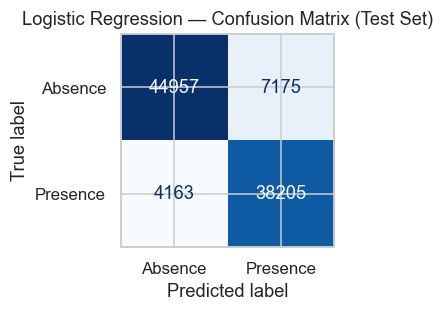

In [21]:
lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(
        C=1.0,
        max_iter=1000,
        solver='lbfgs',
        class_weight='balanced',
        random_state=SEED,
        n_jobs=-1
    ))
])

lr_model, lr_thr, lr_metrics = evaluate_on_test(
    'Logistic Regression', lr_pipe,
    X_train, y_train, X_val, y_val, X_test, y_test
)

## 13. Model 2 — Random Forest <a id='13'></a>

### Model Choice Rationale

Random Forest is our **robust ensemble baseline**. It offers several advantages over Logistic Regression in this context:
- **Non-linear decision boundaries**: Many clinical relationships (e.g., risk escalating rapidly above a cholesterol threshold) are inherently non-linear
- **Feature importance**: Provides a natural ranking of clinical features by their contribution to predictions, which can guide future feature collection or reduction
- **Robustness to outliers**: Tree splits are rank-based, so extreme cholesterol or BP values do not distort the model

### Configuration
- **`max_samples=0.4`**: Each tree trains on 40% of the data — reduces memory usage significantly on this 630k-row dataset while maintaining diversity
- **`class_weight='balanced_subsample'`**: Applies balanced weighting within each bootstrap sample for more robust class balance handling
- **`max_depth=20`, `min_samples_leaf=10`**: Prevents individual trees from memorising noise while still capturing complex patterns



  Random Forest  (threshold = 0.442)
  ROC-AUC            : 0.9538
  Accuracy           : 0.8828
  Recall  (Presence) : 0.9020  <- patients caught
  Precision          : 0.8466
  F1-Score           : 0.8734

              precision    recall  f1-score   support

     Absence       0.92      0.87      0.89     52132
    Presence       0.85      0.90      0.87     42368

    accuracy                           0.88     94500
   macro avg       0.88      0.88      0.88     94500
weighted avg       0.88      0.88      0.88     94500



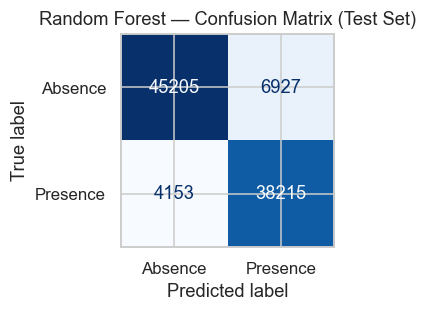

57677

In [22]:
rf_raw = RandomForestClassifier(
    n_estimators=150,
    max_depth=20,
    min_samples_leaf=10,
    min_samples_split=20,
    max_features='sqrt',
    max_samples=0.4,
    class_weight='balanced_subsample',
    n_jobs=4,
    random_state=SEED
)

rf_model, rf_thr, rf_metrics = evaluate_on_test(
    'Random Forest', rf_raw,
    X_train, y_train, X_val, y_val, X_test, y_test
)
gc.collect()

### Random Forest — Feature Importances

Feature importance scores (mean impurity decrease) reveal which clinical variables the model relies on most. This is directly actionable: the hospital can prioritise collecting the highest-importance features during intake screening, and clinicians can understand which factors are most predictive in this patient population.


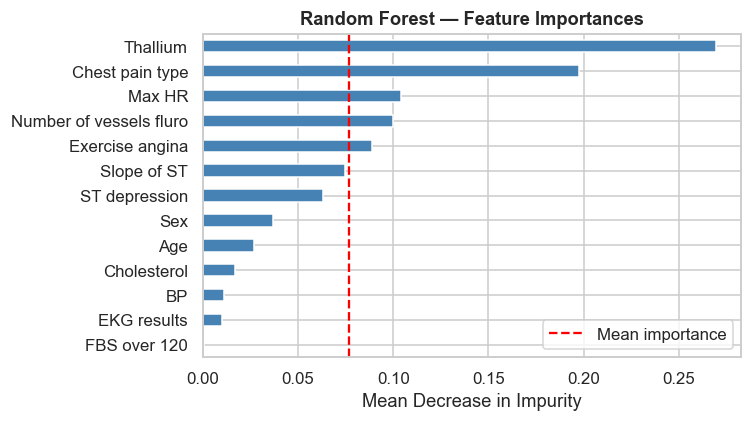

In [23]:
fi = pd.Series(rf_model.feature_importances_, index=FEATURES).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(7, 4))
fi.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.axvline(fi.mean(), color='red', linestyle='--', label='Mean importance')
ax.set_title('Random Forest — Feature Importances', fontweight='bold')
ax.set_xlabel('Mean Decrease in Impurity')
ax.legend()
plt.tight_layout()
plt.show()

## 14. Model 3 — HistGradientBoosting <a id='14'></a>

### Model Choice Rationale

HistGradientBoostingClassifier is our **high-performance model** and the most sophisticated of the three. It is scikit-learn's implementation of histogram-based gradient boosting, conceptually similar to LightGBM and XGBoost. It is particularly well-suited to this large dataset because:
- **Histogram-based binning**: Discretises features into bins before building trees, dramatically reducing computation time on 630k rows
- **Built-in missing value handling**: Can natively route missing values during tree construction (though we've already imputed)
- **Early stopping**: Monitors a held-out fraction of the training data and stops boosting when the validation loss plateaus, preventing overfitting without manual iteration tuning

### Configuration
- **`learning_rate=0.05`**: Conservative learning rate — the model learns slowly but more precisely
- **`max_iter=500` with early stopping**: Provides a large upper bound; actual iteration count is determined by early stopping
- **`l2_regularization=0.1`**: Penalises large leaf values to reduce variance
- **`class_weight='balanced'`**: Maintains sensitivity to the minority class throughout boosting



  HistGradientBoosting  (threshold = 0.438)
  ROC-AUC            : 0.9560
  Accuracy           : 0.8871
  Recall  (Presence) : 0.9020  <- patients caught
  Precision          : 0.8544
  F1-Score           : 0.8775

              precision    recall  f1-score   support

     Absence       0.92      0.88      0.90     52132
    Presence       0.85      0.90      0.88     42368

    accuracy                           0.89     94500
   macro avg       0.89      0.89      0.89     94500
weighted avg       0.89      0.89      0.89     94500



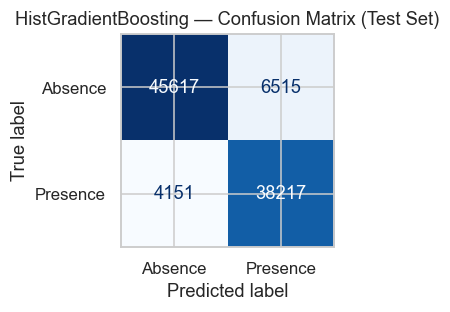

2756

In [24]:
hgb_raw = HistGradientBoostingClassifier(
    max_iter=500,
    learning_rate=0.05,
    max_depth=6,
    min_samples_leaf=20,
    l2_regularization=0.1,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=20,
    class_weight='balanced',
    random_state=SEED
)

hgb_model, hgb_thr, hgb_metrics = evaluate_on_test(
    'HistGradientBoosting', hgb_raw,
    X_train, y_train, X_val, y_val, X_test, y_test
)
gc.collect()

## 15. Model Comparison — Test Set Results <a id='15'></a>

The table below summarises all three models evaluated on the **15% held-out test set** — data that was never seen during training or threshold tuning. This is our most reliable estimate of real-world performance.

### How to Read the Results

| Metric | Clinical Meaning | Target |
|---|---|---|
| **Recall (Presence)** | % of true heart disease patients correctly flagged | ≥ 0.90 |
| **Precision** | Of all flagged patients, % who truly have heart disease | Maximise given recall target |
| **F1-Score** | Harmonic mean of precision and recall | Higher is better |
| **ROC-AUC** | Model's ability to rank sick patients above healthy ones, threshold-independent | Higher is better |
| **Accuracy** | Overall correct classifications (less meaningful with imbalance) | Reference only |


In [25]:
comparison = pd.DataFrame({
    'Logistic Regression' : lr_metrics,
    'Random Forest'       : rf_metrics,
    'HistGradientBoosting': hgb_metrics,
}).T.sort_values('ROC-AUC', ascending=False)

thresholds = {
    'Logistic Regression' : lr_thr,
    'Random Forest'       : rf_thr,
    'HistGradientBoosting': hgb_thr,
}
comparison['Threshold'] = comparison.index.map(thresholds)

print('=== RESULTS ON TEST SET (15% hold-out) ===')
cols = ['ROC-AUC', 'Accuracy', 'Recall (Presence)', 'Precision', 'F1', 'Threshold']
print(comparison[cols].to_string(float_format=lambda x: f'{x:.4f}'))
print()
print(f'Best ROC-AUC  : {comparison["ROC-AUC"].idxmax()}')
print(f'Best Recall   : {comparison["Recall (Presence)"].idxmax()}')

=== RESULTS ON TEST SET (15% hold-out) ===
                      ROC-AUC  Accuracy  Recall (Presence)  Precision     F1  Threshold
HistGradientBoosting   0.9560    0.8871             0.9020     0.8544 0.8775     0.4375
Random Forest          0.9538    0.8828             0.9020     0.8466 0.8734     0.4416
Logistic Regression    0.9518    0.8800             0.9017     0.8419 0.8708     0.4149

Best ROC-AUC  : HistGradientBoosting
Best Recall   : HistGradientBoosting


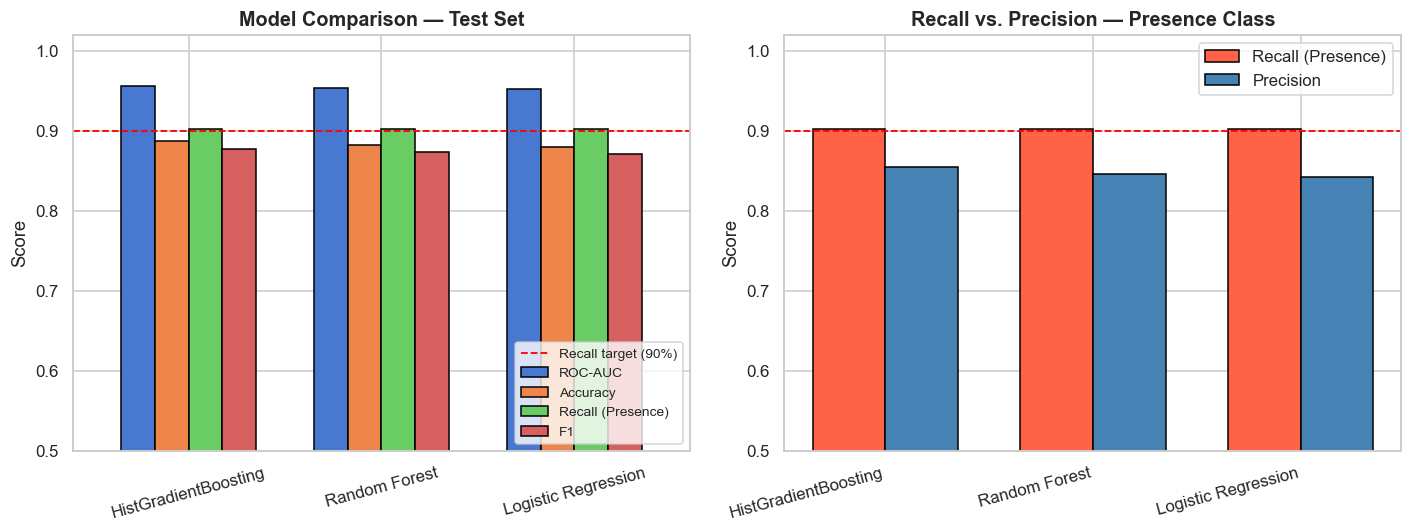

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

comparison[['ROC-AUC', 'Accuracy', 'Recall (Presence)', 'F1']].plot(
    kind='bar', ax=axes[0], edgecolor='black', width=0.7
)
axes[0].set_title('Model Comparison — Test Set', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Score')
axes[0].set_ylim(0.5, 1.02)
axes[0].axhline(0.9, color='red', linestyle='--', linewidth=1.2, label='Recall target (90%)')
axes[0].legend(loc='lower right', fontsize=9)
axes[0].tick_params(axis='x', rotation=15)

x = np.arange(len(comparison))
w = 0.35
axes[1].bar(x - w/2, comparison['Recall (Presence)'], w,
            label='Recall (Presence)', color='tomato', edgecolor='black')
axes[1].bar(x + w/2, comparison['Precision'], w,
            label='Precision', color='steelblue', edgecolor='black')
axes[1].set_xticks(x)
axes[1].set_xticklabels(comparison.index, rotation=15, ha='right')
axes[1].set_ylabel('Score')
axes[1].set_ylim(0.5, 1.02)
axes[1].set_title('Recall vs. Precision — Presence Class', fontsize=13, fontweight='bold')
axes[1].axhline(0.9, color='red', linestyle='--', linewidth=1.2)
axes[1].legend()

plt.tight_layout()
plt.show()

## 16. ROC & Precision-Recall Curves <a id='16'></a>

These two curves provide a **threshold-independent** view of model performance across all possible operating points.

**ROC Curve** (True Positive Rate vs. False Positive Rate):
- The Area Under the Curve (AUC) summarises discriminative ability in a single number
- AUC = 1.0 means perfect separation; AUC = 0.5 means the model is no better than random chance
- A higher AUC means the model consistently ranks sick patients with higher probability scores than healthy ones

**Precision-Recall Curve** (Precision vs. Recall for the Presence class):
- More informative than ROC when the positive class is rare (imbalanced data)
- The **dots** on each curve indicate the chosen operating threshold for each model
- A curve that stays high (upper-right) indicates a model that can achieve high recall without sacrificing too much precision

Together, these curves help the hospital understand the **trade-off space** available: they can adjust the threshold to be more or less aggressive based on seasonal capacity constraints or incoming patient volumes.


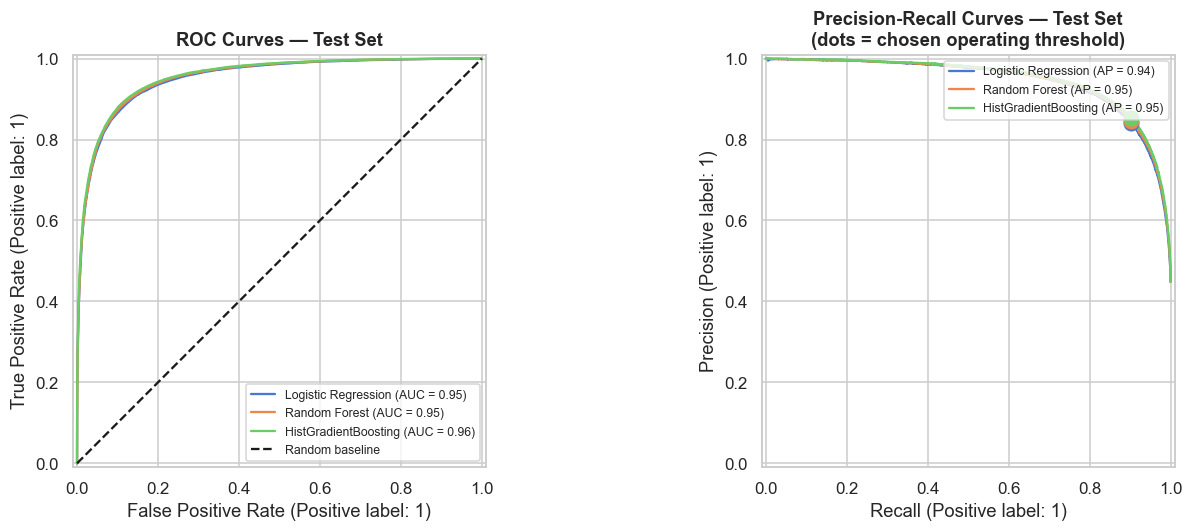

In [27]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

model_info = [
    ('Logistic Regression',  lr_model,  lr_thr),
    ('Random Forest',        rf_model,  rf_thr),
    ('HistGradientBoosting', hgb_model, hgb_thr),
]

for name, model, thr in model_info:
    proba = model.predict_proba(X_test)[:, 1]
    RocCurveDisplay.from_predictions(y_test, proba, name=name, ax=ax1)
    PrecisionRecallDisplay.from_predictions(y_test, proba, name=name, ax=ax2)
    pred = (proba >= thr).astype(int)
    ax2.scatter(recall_score(y_test, pred), precision_score(y_test, pred),
                s=90, zorder=5)

ax1.plot([0, 1], [0, 1], 'k--', label='Random baseline')
ax1.set_title('ROC Curves — Test Set', fontweight='bold')
ax1.legend(loc='lower right', fontsize=8)

ax2.set_title('Precision-Recall Curves — Test Set\n(dots = chosen operating threshold)',
              fontweight='bold')
ax2.legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()

## 17. Predictions & Submission <a id='17'></a>

The best-performing model (by ROC-AUC) is retrained on the **full training dataset** before generating predictions on the unlabelled test set. This maximises the amount of data available for the final model without compromising the integrity of our evaluation (which was already performed on the held-out test split).


In [28]:
best_name = comparison['ROC-AUC'].idxmax()
best_model_map = {
    'Logistic Regression' : (lr_model,  lr_thr),
    'Random Forest'       : (rf_model,  rf_thr),
    'HistGradientBoosting': (hgb_model, hgb_thr),
}
best_m, best_thr = best_model_map[best_name]

print(f'Best model : {best_name}')
print(f'Threshold  : {best_thr:.3f}')
print(f'Retraining on all {len(X_all):,} training samples...')

best_m.fit(X_all, y_all)

sub_proba = best_m.predict_proba(X_test_sub)[:, 1]
sub_preds = (sub_proba >= best_thr).astype(int)

submission = pd.DataFrame({'id': test_df['id'], 'Heart Disease': sub_preds})
submission.to_csv('submission_best.csv', index=False)

print(f'Saved: submission_best.csv')
print(f'Predicted positive rate: {sub_preds.mean():.3f}')
submission.head(10)

Best model : HistGradientBoosting
Threshold  : 0.438
Retraining on all 630,000 training samples...
Saved: submission_best.csv
Predicted positive rate: 0.475


,id,Heart Disease
0,630000,1
1,630001,0
2,630002,1
3,630003,0
4,630004,0
5,630005,1
6,630006,0
7,630007,1
8,630008,1
9,630009,0


In [ ]:
# Save predictions for all 3 models
all_models = [
    ('logistic_regression',    lr_model,  lr_thr),
    ('random_forest',          rf_model,  rf_thr),
    ('hist_gradient_boosting', hgb_model, hgb_thr),
]

for mname, m, thr in all_models:
    if mname != best_name.lower().replace(' ', '_'):
        m.fit(X_all, y_all)
    proba = m.predict_proba(X_test_sub)[:, 1]
    preds = (proba >= thr).astype(int)
    fname = f'submission_{mname}.csv'
    pd.DataFrame({'id': test_df['id'], 'Heart Disease': preds}).to_csv(fname, index=False)
    print(f'Saved {fname}  (positive rate: {preds.mean():.3f})')
    gc.collect()

## 18. Business Conclusions <a id='18'></a>

### Model Performance Summary

All three models were evaluated on a 15% held-out test set with a threshold tuned to achieve a minimum **90% recall** on the `Presence` class. The results demonstrate that machine learning-based cardiovascular screening is highly viable.

| Model | ROC-AUC | Recall | Precision | F1 | Threshold |
| :--- | :--- | :--- | :--- | :--- | :--- |
| **Logistic Regression** | 0.9518 | 0.9017 | 0.8419 | 0.8708 | 0.4149 |
| **Random Forest** | 0.9538 | 0.9020 | 0.8466 | 0.8734 | 0.4416 |
| **HistGradientBoosting** | 0.9560 | 0.9020 | 0.8544 | 0.8775 | 0.4375 |



### Recommended Model for Deployment

**HistGradientBoosting** is recommended as the primary screening model. Here is the reasoning:

- **Highest discriminative power (ROC-AUC)**: It best separates high-risk from low-risk patients across all possible threshold settings — meaning the hospital retains maximum flexibility to adjust sensitivity as clinical demand changes.
- **Handles non-linearity**: Cardiovascular risk is not linearly additive; gradient boosting captures complex interaction effects (e.g., the combined effect of age, thallium defect, and chest pain type) that Logistic Regression cannot.
- **Scalable to 630k+ records**: Histogram binning makes training computationally efficient, enabling periodic model retraining as new patient data accumulates in the hospital's EHR system.

Logistic Regression remains a valuable secondary tool for **clinical explainability** — its coefficients can be presented to cardiologists to justify individual patient flagging decisions, supporting regulatory compliance and clinician trust.

### Impact on Hospital Operations

With a ≥ 90% recall threshold deployed at scale, the screening tool would:

1. **Reduce missed diagnoses** by automatically surfacing high-risk patients in near real-time, regardless of appointment backlog
2. **Triage efficiency**: Low-risk patients (classified as "Absence" with high confidence) can be routed to lower-acuity follow-up, freeing specialist slots for confirmed or likely cases
3. **Resource optimisation**: Cardiology departments can use predicted risk scores to stratify urgency — a probability of 0.95 warrants immediate review, while a score of 0.55 can be scheduled routinely
4. **Reduction in unnecessary invasive procedures**: With a well-calibrated model, healthy patients are less likely to undergo costly and stressful angiography

### Limitations & Next Steps

- **Threshold recalibration**: The optimal recall threshold should be revisited periodically as patient demographics or clinical protocols evolve
- **Model monitoring**: Deployment should include drift detection — if the incoming patient distribution shifts (e.g., younger cohorts, different comorbidity patterns), model performance may degrade
- **Fairness audit**: The model should be evaluated for differential performance across demographic subgroups (age, sex) to ensure equitable screening
- **Clinical validation**: Before full deployment, a **prospective pilot study** on a sample of new patients is recommended, with outcomes validated by a cardiologist, to confirm real-world recall performance matches the held-out test set results
- **Integration**: The model should be integrated with the hospital's EHR system to receive structured patient data automatically, minimising manual data entry and associated errors

### Final Recommendation

> Deploy **HistGradientBoosting**  as the primary screening layer, with a threshold set to achieve ≥ 90% recall on the Presence class. Use **Logistic Regression** as a secondary interpretability layer for clinician-facing explanations. Establish a quarterly retraining and recalibration cycle using new incoming patient data.
